# Phase 1
## Dataset
AG News
## Metrics: 
1. Acc
2. Brier Score
3. Expected Calibration Error (ECE)
4. Expected Reducble Uncertatinty (ERU)
5. Predictive Discrepecy (OOD AUROC) - P Dist
6. Predictive Dispersion (P-Disp)



In [15]:
!pip install datasets
!pip install scikit-learn
!pip install transformers
!pip install torch
!pip install torchmetrics
!pip install matplotlib
!pip install seaborn

In [16]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
from transformers import AutoModel, AutoTokenizer, set_seed
from datasets import load_dataset
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

# ==========================================
# 1. Environment Setup
# ==========================================

In [17]:
def setup_environment():
    set_seed(42)
    os.makedirs("data/", exist_ok=True)
    os.makedirs("reports/phase1/", exist_ok=True)
    print("Environment setup complete. Seed=42.")

# MPS detection + speed tweaks
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using Apple MPS (M2 accelerated)")
    torch.set_float32_matmul_precision('high')   # critical for speed on MPS
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("⚠️  Running on CPU – will be slow")
print(f"Device: {device}")

✅ Using Apple MPS (M2 accelerated)
Device: mps


# ==========================================
# 2. Data Pipeline
# ==========================================

In [ ]:
def prepare_datasets():
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    
    def tokenize_func(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    ag_news = load_dataset("ag_news", cache_dir="data/")
    train_val_split = ag_news["train"].train_test_split(test_size=6000, seed=42)
    train_data = train_val_split["train"]
    val_data = train_val_split["test"]
    clean_test = ag_news["test"]

    def make_noisy_test(clean_test, noise_rate=0.2, seed=42):
        rng = random.Random(seed)
        n = len(clean_test)
        k = int(n * noise_rate)
        flip_index = rng.sample(range(n), k)

        def inject_noise(example, idx):
            is_flipped = idx in flip_index
            if is_flipped:
                original_label = example["label"]
                possible_flips = [l for l in range(4) if l != original_label]
                example["label"] = random.choice(possible_flips)
            example["is_flipped"] = is_flipped
            return example
        return clean_test.map(inject_noise, with_indices=True)

    noisy_test = make_noisy_test(clean_test, noise_rate=0.2, seed=42)

    imdb = load_dataset("imdb", split="test", cache_dir="data/")
    ood_test = imdb.select(range(3000))
    ood_test = ood_test.map(lambda x: {"label": 0})

    # Tokenize (cached)
    encoded_train = train_data.map(tokenize_func, batched=True).with_format("torch", columns=["input_ids", "attention_mask", "label"])
    encoded_val = val_data.map(tokenize_func, batched=True).with_format("torch", columns=["input_ids", "attention_mask", "label"])
    encoded_clean_test = clean_test.map(tokenize_func, batched=True).with_format("torch", columns=["input_ids", "attention_mask", "label"])
    encoded_noisy_test = noisy_test.map(tokenize_func, batched=True).with_format("torch", columns=["input_ids", "attention_mask", "label", "is_flipped"])
    encoded_ood_test = ood_test.map(tokenize_func, batched=True).with_format("torch", columns=["input_ids", "attention_mask", "label"])

    return encoded_train, encoded_val, encoded_clean_test, encoded_noisy_test, encoded_ood_test

# ==========================================
# 3. Model & Loss
# ==========================================

In [ ]:
class EvidentialHead(nn.Module):
    def __init__(self, input_dim=768, num_classes=4):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

        # Initialize temperature at 1.0 (no scaling)
        self.register_buffer('temperature', torch.ones(1))

    def set_temperature(self, temp: float):
        if temp <= 0:
            raise ValueError("temperature must be > 0")
        self.temperature.fill_(float(temp))

    def forward(self, features, temp=None):
        # Use provided temp for calibration, otherwise use stored value
        t = temp if temp is not None else self.temperature
        raw_logits = self.linear(features)
        # Apply temperature scaling at the logit level
        scaled_logits = raw_logits / t
        # Generate evidence and alpha parameters
        evidence = F.softplus(scaled_logits)           # e >= 0
        alpha = evidence + 1.0                         # alpha >= 1
        return evidence, alpha

class BertWithEvidentialHead(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.bert = AutoModel.from_pretrained("bert-base-uncased")
        for p in self.bert.parameters():
            p.requires_grad = False
        self.bert.eval()
        
        self.head = EvidentialHead(768, num_classes)

    def forward(self, input_ids=None, attention_mask=None, temp=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, **kwargs)
        cls = outputs.last_hidden_state[:, 0, :]
        
        # Pass the temperature to the head
        return self.head(cls, temp=temp)

# v3.1 - Add label smoothing to Brier loss to prevent overconfidence on noisy labels, which can destabilize training and hurt P-Disp.
def get_expected_probs(alpha):
    S = alpha.sum(dim=1, keepdim=True).clamp_min(1e-12)
    return alpha / S

# V3.0 Replace your current kl_divergence_penalty with this refined version
def kl_divergence_penalty(alpha, one_hot, num_classes=4, eps=1e-12):
    """
    Refined KL: ONLY penalize evidence on the 3 incorrect classes.
    Correct-class evidence is fixed at 1 (no penalty).
    This keeps high confidence on clean data while forcing vacuity on OOD.
    """
    wrong_mask = 1.0 - one_hot  # 1 on incorrect classes, 0 on correct
    beta = one_hot + wrong_mask * alpha   # correct class β=1, wrong classes get α penalized
    S_beta = torch.sum(beta, dim=1, keepdim=True).clamp_min(eps)

    term1 = torch.lgamma(S_beta) - torch.lgamma(torch.tensor(float(num_classes), device=alpha.device))
    term2 = -torch.sum(torch.lgamma(beta), dim=1, keepdim=True)
    term3 = torch.sum((beta - 1.0) * (torch.digamma(beta) - torch.digamma(S_beta)), dim=1, keepdim=True)

    kl_loss = term1 + term2 + term3
    return kl_loss.mean()

def quick_gradient_check(model, num_classes=4):
    model.train()
    input_ids = torch.randint(0, 30522, (2, 8), device=device)
    attention_mask = torch.ones_like(input_ids)
    target = torch.randint(0, num_classes, (2,), device=device)

    _, alpha = model(input_ids=input_ids, attention_mask=attention_mask)
    loss = brier_score_loss(alpha, target, num_classes=num_classes)
    assert torch.isfinite(loss).all(), "Loss has NaN/Inf"
    
    model.zero_grad()
    loss.backward()
    head_grads = [p.grad for p in model.head.parameters() if p.requires_grad]
    assert all(g is not None for g in head_grads), "No grads on head"
    assert all(torch.isfinite(g).all() for g in head_grads), "NaN/Inf in head grads"
    print("Gradient check passed.")

# ==========================================
# 4. Metrics Implementation
# ==========================================

In [ ]:
def base_accuracy(alpha, target):
    p_mean = get_expected_probs(alpha)
    preds = torch.argmax(p_mean, dim=1)
    return (preds == target).float().mean()

def get_smoothed_one_hot(labels, num_classes=4, epsilon=0.05):
    """
    Create smoothed one-hot targets for label smoothing.
    (1-ε) * hard_onehot + ε/num_classes
    Introduces controlled aleatoric uncertainty → prevents Dirichlet collapse,
    improves calibration, and gives P-Disp proxy signal.
    """
    one_hot = torch.zeros(labels.size(0), num_classes, device=labels.device)
    one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
    smoothed = (1 - epsilon) * one_hot + (epsilon / num_classes)
    return smoothed

def mixup_embeddings(cls_features, one_hot, alpha=0.2):
    """Proper Mixup for frozen BERT: mix continuous CLS embeddings + labels"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = cls_features.size(0)
    index = torch.randperm(batch_size).to(cls_features.device)
    
    mixed_cls = lam * cls_features + (1 - lam) * cls_features[index]
    mixed_onehot = lam * one_hot + (1 - lam) * one_hot[index]
    return mixed_cls, mixed_onehot, lam

def get_ood_batch(ood_iter, ood_loader):
    """Safe iterator with auto-reset that properly returns the fresh iterator."""
    try:
        batch = next(ood_iter)
    except StopIteration:
        ood_iter = iter(ood_loader) 
        batch = next(ood_iter)
    return batch, ood_iter

def brier_score_loss(alpha, target_or_onehot, num_classes=4):
    """
    Brier Score on Dirichlet mean.
    Now accepts either:
      - integer labels (dim=1) → creates hard one-hot internally
      - pre-smoothed one-hot tensor (dim=2)
    """
    p_hat = get_expected_probs(alpha)
    if target_or_onehot.dim() == 1:  # legacy integer labels
        one_hot = torch.zeros(target_or_onehot.size(0), num_classes, device=target_or_onehot.device)
        one_hot.scatter_(1, target_or_onehot.unsqueeze(1), 1.0)
    else:
        one_hot = target_or_onehot  # already smoothed
    return torch.mean(torch.sum((p_hat - one_hot) ** 2, dim=1))

def _ece_from_probs(probs, target, n_bins=15):
    conf, preds = probs.max(dim=1)
    acc = preds.eq(target).float()
    bins = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    ece = torch.zeros(1, device=probs.device)
    for i in range(n_bins):
        mask = (conf >= bins[i]) & (conf <= bins[i + 1]) if i == n_bins - 1 else (conf >= bins[i]) & (conf < bins[i + 1])
        if mask.any():
            ece += mask.float().mean() * (conf[mask].mean() - acc[mask].mean()).abs()
    return ece.squeeze(0)

def eru_mutual_information(alpha, eps=1e-12):
    S = alpha.sum(dim=1, keepdim=True).clamp_min(eps)
    p_mean = alpha / S
    predictive_entropy = -torch.sum(p_mean * torch.log(p_mean.clamp_min(eps)), dim=1)
    expected_entropy = -torch.sum((alpha / S) * (torch.digamma(alpha + 1) - torch.digamma(S + 1)), dim=1)
    return predictive_entropy - expected_entropy

def p_disc_auroc(alpha_clean, alpha_ood):
    try:
        from torchmetrics.classification import BinaryAUROC
    except ImportError:
        raise ImportError("Please install torchmetrics for AUROC calculation")
        
    # Replace the marginal KL calculation with your ERU Mutual Information
    scores_clean = eru_mutual_information(alpha_clean)
    scores_ood = eru_mutual_information(alpha_ood)
    
    scores = torch.cat([scores_clean, scores_ood], dim=0)
    labels = torch.cat([torch.zeros_like(scores_clean, dtype=torch.long), 
                        torch.ones_like(scores_ood, dtype=torch.long)], dim=0)
    
    metric = BinaryAUROC().to(scores.device)
    return metric(scores, labels)

def p_disp_cohens_d(alpha, is_flipped):
    """Fixed: uses full test set, simplified signature"""
    ent = -torch.sum(get_expected_probs(alpha) * torch.log(get_expected_probs(alpha).clamp_min(1e-12)), dim=1)
    
    flipped_mask = is_flipped.bool()
    ent_flipped = ent[flipped_mask] if flipped_mask.any() else ent
    ent_clean_only = ent[~flipped_mask] if (~flipped_mask).any() else ent
    
    if len(ent_flipped) < 2 or len(ent_clean_only) < 2:
        return 0.0
    
    v1, v2 = ent_flipped.var(unbiased=False), ent_clean_only.var(unbiased=False)
    n1, n2 = ent_flipped.numel(), ent_clean_only.numel()
    pooled_std = torch.sqrt(((n1 * v1) + (n2 * v2)) / (n1 + n2) + 1e-12)
    return (ent_flipped.mean() - ent_clean_only.mean()) / pooled_std

# ==========================================
# 5. Visualization
# ==========================================

In [ ]:
def get_expected_probs(alpha, eps=1e-12):
    strength = alpha.sum(dim=1, keepdim=True).clamp_min(eps)
    return alpha / strength


def _kl_p_mean_expected(p_mean, expected_p, eps=1e-12):
    if expected_p.dim() == 1:
        expected_p = expected_p.unsqueeze(0)
    expected_p = expected_p / expected_p.sum(dim=1, keepdim=True).clamp_min(eps)
    return torch.sum(
        p_mean.clamp_min(eps)
        * (
            torch.log(p_mean.clamp_min(eps))
            - torch.log(expected_p.clamp_min(eps))
        ),
        dim=1,
    )


def _to_scalar(x):
    if torch.is_tensor(x):
        return float(x.detach().cpu().item()) if x.numel() == 1 else float(x.detach().cpu().mean().item())
    return float(x)


def save_phase1_visualizations(
    train_losses,
    val_accs,
    epoch_times,
    alpha_clean,
    targets_clean,
    alpha_noisy,
    alpha_ood,
    metrics_dict,
    save_dir="reports/phase1",
):
    """
    Save Phase 1 snapshot visualizations for evidential outputs.

    Expected arguments match phase1.py:
      - train_losses, val_accs, epoch_times
      - alpha_clean, targets_clean, alpha_noisy, alpha_ood
      - metrics_dict with keys like:
        Accuracy, Brier, ECE, ERU, P-Disc, P-Disp
    """
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    sns.set_style("whitegrid")

    # Convert metric values (torch scalars -> float)
    metrics_dict = {k: _to_scalar(v) for k, v in metrics_dict.items()}

    # Shared probabilities
    p_mean_clean = get_expected_probs(alpha_clean)
    p_mean_noisy = get_expected_probs(alpha_noisy)
    p_mean_ood = get_expected_probs(alpha_ood)

    # 1) Training curves
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    epochs = range(1, len(train_losses) + 1)

    axs[0].plot(epochs, train_losses, "b-o", linewidth=2)
    axs[0].set_title("Train Loss (Brier)")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")

    axs[1].plot(epochs, val_accs, "g-o", linewidth=2)
    axs[1].set_title("Validation Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")

    axs[2].bar(epochs, epoch_times, color="orange")
    axs[2].set_title("Time per Epoch (seconds)")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("Seconds")

    fig.tight_layout()
    fig.savefig(f"{save_dir}/training_curves.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # 2) Reliability diagram
    conf, preds = p_mean_clean.max(dim=1)
    acc = preds.eq(targets_clean).float()
    bins = torch.linspace(0, 1, 16, device=conf.device)
    bin_acc, bin_conf, bin_count = [], [], []

    for i in range(15):
        if i == 14:
            mask = (conf >= bins[i]) & (conf <= bins[i + 1])
        else:
            mask = (conf >= bins[i]) & (conf < bins[i + 1])
        if mask.any():
            bin_conf.append(conf[mask].mean().item())
            bin_acc.append(acc[mask].mean().item())
            bin_count.append(mask.sum().item())

    fig = plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    if bin_conf:
        plt.scatter(bin_conf, bin_acc, s=80, c=bin_count, cmap="Blues", edgecolors="black")
        plt.colorbar(label="Samples per bin")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram (ECE = {metrics_dict.get('ECE', 0.0):.4f})")
    plt.legend()
    fig.savefig(f"{save_dir}/reliability_diagram.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # 3) Entropy distribution (clean vs noisy)
    ent_clean = (
        -torch.sum(p_mean_clean * torch.log(p_mean_clean.clamp_min(1e-12)), dim=1)
        .detach()
        .cpu()
        .numpy()
    )
    ent_noisy = (
        -torch.sum(p_mean_noisy * torch.log(p_mean_noisy.clamp_min(1e-12)), dim=1)
        .detach()
        .cpu()
        .numpy()
    )

    fig = plt.figure(figsize=(8, 6))
    sns.boxplot(data=[ent_clean, ent_noisy], notch=True)
    plt.xticks([0, 1], ["Clean Test", "20% Noisy"])
    plt.ylabel("Predictive Entropy")
    plt.title(f"P-Disp: Cohen's d = {metrics_dict.get('P-Disp', 0.0):.3f}")
    fig.savefig(f"{save_dir}/entropy_distribution.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # 4) KL discrepancy histogram
    expected_p = p_mean_clean.mean(dim=0)
    kl_clean = _kl_p_mean_expected(p_mean_clean, expected_p).detach().cpu().numpy()
    kl_ood = _kl_p_mean_expected(p_mean_ood, expected_p).detach().cpu().numpy()

    fig = plt.figure(figsize=(9, 6))
    sns.histplot(kl_clean, kde=True, color="blue", label="Clean (ID)", alpha=0.7, bins=50)
    sns.histplot(kl_ood, kde=True, color="red", label="OOD (IMDB)", alpha=0.7, bins=50)
    plt.axvline(kl_clean.mean(), color="blue", linestyle="--")
    plt.axvline(kl_ood.mean(), color="red", linestyle="--")
    plt.xlabel("KL(p_mean || E[p])")
    plt.ylabel("Count")
    plt.title(f"P-Disc: AUROC = {metrics_dict.get('P-Disc', 0.0):.4f}")
    plt.legend()
    fig.savefig(f"{save_dir}/kl_discrepancy.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # 5) Metrics summary bar chart
    df = pd.DataFrame({"Metric": list(metrics_dict.keys()), "Value": list(metrics_dict.values())})

    fig = plt.figure(figsize=(10, 6))
    bars = plt.bar(df["Metric"], df["Value"], color="steelblue")
    plt.ylabel("Value")
    plt.title("Phase 1 Final Metrics")
    plt.xticks(rotation=45, ha="right")
    for bar, val in zip(bars, df["Value"]):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{val:.3f}", ha="center")
    plt.tight_layout()
    fig.savefig(f"{save_dir}/metrics_summary.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    # 6) Markdown summary
    with open(f"{save_dir}/phase1_report.md", "w") as f:
        f.write("# Phase 1 - Snapshot Report\n\n")
        f.write("## Final Metrics\n")
        try:
            f.write(df.to_markdown(index=False))
        except Exception:
            f.write(df.to_string(index=False))
        f.write("\n\n## Visuals\n")
        f.write("![Training Curves](training_curves.png)\n")
        f.write("![Reliability](reliability_diagram.png)\n")
        f.write("![Entropy](entropy_distribution.png)\n")
        f.write("![KL](kl_discrepancy.png)\n")
        f.write("![Metrics](metrics_summary.png)\n")


# ==========================================
# 6. Training Loop & Evaluation
# ==========================================

In [23]:
def extract_tensors(batch):
    return batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["label"].to(device)

def get_all_alphas_and_targets(model, dataloader):
    model.eval()
    all_alphas, all_targets = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attn_mask, labels = extract_tensors(batch)
            _, alpha = model(input_ids=input_ids, attention_mask=attn_mask)
            all_alphas.append(alpha)
            all_targets.append(labels)
    return torch.cat(all_alphas), torch.cat(all_targets)

def extract_tensors(batch):
    return batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["label"].to(device)

def get_all_alphas_and_targets(model, dataloader):
    model.eval()
    all_alphas, all_targets = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids, attn_mask, labels = extract_tensors(batch)
            _, alpha = model(input_ids=input_ids, attention_mask=attn_mask)
            all_alphas.append(alpha)
            all_targets.append(labels)
    return torch.cat(all_alphas), torch.cat(all_targets)

def train_and_evaluate():
    setup_environment()
    train_data, val_data, clean_test, noisy_test, ood_test = prepare_datasets()
    
    train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_data,   batch_size=256, shuffle=False, num_workers=0)
    ood_loader   = DataLoader(ood_test,   batch_size=128, shuffle=True, num_workers=0)
    
    ood_iter = iter(ood_loader)

    model = BertWithEvidentialHead(num_classes=4).to(device)
    # Unfreeze only the final transformer block for light backbone adaptation.
    for p in model.bert.encoder.layer[11].parameters():
        p.requires_grad = True

    shared_temp = 1.0
    model.head.set_temperature(shared_temp)
    quick_gradient_check(model)

    layer11_params = list(model.bert.encoder.layer[11].parameters())
    optimizer = optim.AdamW(
        [
            {"params": model.head.parameters(), "lr": 5e-4},
            {"params": layer11_params, "lr": 1e-5},
        ],
        weight_decay=1e-3,
    )
    label_smoothing_eps = 0.02
    epochs = 5
    ood_exposure_every = 3
    train_losses, val_accs, epoch_times = [], [], []

    print("\n--- Starting Training (Clean Ablation: Base Brier + OOD Exposure) ---")
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0
        batch_idx = 0

        epoch_start_time = time.time()
        
        for batch in train_loader:
            batch_idx += 1
            input_ids, attn_mask, labels = extract_tensors(batch)
            one_hot = get_smoothed_one_hot(labels, num_classes=4, epsilon=label_smoothing_eps)
            
            # === Forward BERT ONCE (Layer 11 is trainable) ===
            outputs = model.bert(input_ids=input_ids, attention_mask=attn_mask)
            cls = outputs.last_hidden_state[:, 0, :]
            
            # === Head only (cheap) - NO MIXUP ===
            # Uses shared model.head.temperature across train/OOD/eval.
            _, alpha = model.head(cls)
            
            # === Base Decision-Theoretic Loss Only ===
            loss = brier_score_loss(alpha, one_hot)
            
            # === OOD exposure (Fixed control-flow) ===
            if batch_idx % ood_exposure_every == 0:
                ood_batch, ood_iter = get_ood_batch(ood_iter, ood_loader)
                ood_ids, ood_mask, _ = extract_tensors(ood_batch)
                _, ood_alpha = model(input_ids=ood_ids, attention_mask=ood_mask)
                vacuity_loss = 0.1 * ood_alpha.mean()
                loss = loss + vacuity_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * labels.size(0)
            total_count += labels.size(0)
        
        # Validation
        val_alphas, val_targets = get_all_alphas_and_targets(model, val_loader)
        val_acc = base_accuracy(val_alphas, val_targets).item()
        epoch_time = time.time() - epoch_start_time

        train_losses.append(total_loss / total_count)
        val_accs.append(val_acc)
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch}/{epochs} | Train Loss: {total_loss/total_count:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")

    print("\n--- Running Full Metric Suite ---")
    test_loader = lambda ds: DataLoader(ds, batch_size=256, shuffle=False, num_workers=0)
    alpha_clean, targets_clean = get_all_alphas_and_targets(model, test_loader(clean_test))
    alpha_noisy, _ = get_all_alphas_and_targets(model, test_loader(noisy_test))
    alpha_ood, _   = get_all_alphas_and_targets(model, test_loader(ood_test))

    # Metrics computation
    clean_acc = base_accuracy(alpha_clean, targets_clean)
    clean_brier = brier_score_loss(alpha_clean, targets_clean, num_classes=4)
    clean_ece = _ece_from_probs(get_expected_probs(alpha_clean), targets_clean, n_bins=15)
    clean_eru = eru_mutual_information(alpha_clean).mean()
    auroc = p_disc_auroc(alpha_clean, alpha_ood)
    
    # Safely gather is_flipped flags
    test_loader_noisy = test_loader(noisy_test)
    all_is_flipped = []
    with torch.no_grad():
        for batch in test_loader_noisy:
            if "is_flipped" in batch:
                all_is_flipped.append(batch["is_flipped"].to(device))
    
    is_flipped_tensor = torch.cat(all_is_flipped) if all_is_flipped else None
    
    if is_flipped_tensor is not None and is_flipped_tensor.shape[0] == alpha_noisy.shape[0]:
        cohens_d = p_disp_cohens_d(alpha_noisy, is_flipped_tensor)
    else:
        cohens_d = 0.0
        print("Warning: is_flipped collection failed or shape mismatch → P-Disp set to 0")

    # Document-recommended structured outputs
    print("\n1. Predictive Performance / Calibration")
    print(f"   Accuracy: {clean_acc:.4f}")
    print(f"   Brier:    {clean_brier:.4f}")
    print(f"   ECE:      {clean_ece:.4f}")

    print("\n2. OOD / Epistemic Proxy")
    print(f"   P-Disc (AUROC): {auroc:.4f}")
    print(f"   ERU / MI:       {clean_eru:.4f}")

    print("\n3. Corruption Sensitivity")
    print(f"   P-Disp (d): {cohens_d:.4f}")
    
    print("\n--- Diagnostics ---")
    print(f"Mean Strength S (clean): {alpha_clean.sum(dim=1).mean():.1f}")
    print(f"Mean Strength S (OOD):   {alpha_ood.sum(dim=1).mean():.1f}")
    # === VISUALIZE ===
    metrics_dict = {
        "Accuracy": clean_acc,
        "Brier": clean_brier,
        "ECE": clean_ece,
        "ERU": clean_eru,
        "P-Disc": auroc,
        "P-Disp": cohens_d
    }
    save_phase1_visualizations(train_losses, val_accs, epoch_times,
                               alpha_clean, targets_clean,
                               alpha_noisy, alpha_ood,
                               metrics_dict)
    
    print(f"\n✅ All plots saved to reports/phase1/")


# ==========================================
# 7. Run Code
# ==========================================

In [24]:
if __name__ == "__main__":
    train_and_evaluate()

Environment setup complete. Seed=42.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2007.52it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gradient check passed.

--- Starting Training (Clean Ablation: Base Brier + OOD Exposure) ---
Epoch 1/5 | Train Loss: 0.2358 | Val Acc: 0.9048 | Time: 3244.2s
Epoch 2/5 | Train Loss: 0.1690 | Val Acc: 0.9108 | Time: 4399.5s
Epoch 3/5 | Train Loss: 0.1574 | Val Acc: 0.9182 | Time: 17496.0s
Epoch 4/5 | Train Loss: 0.1484 | Val Acc: 0.9233 | Time: 3555.4s
Epoch 5/5 | Train Loss: 0.1422 | Val Acc: 0.9268 | Time: 35231.5s

--- Running Full Metric Suite ---

1. Predictive Performance / Calibration
   Accuracy: 0.9286
   Brier:    0.1122
   ECE:      0.0403

2. OOD / Epistemic Proxy
   P-Disc (AUROC): 1.0000
   ERU / MI:       0.0296

3. Corruption Sensitivity
   P-Disp (d): 0.0665

--- Diagnostics ---
Mean Strength S (clean): 47.9
Mean Strength S (OOD):   4.0

✅ All plots saved to reports/phase1/


Environment setup complete. Seed=42.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1065.74it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gradient check passed.

--- Starting Training (Clean Ablation: Base Brier + OOD Exposure) ---
Epoch 1/5 | Train Loss: 0.3734 | Val Acc: 0.8592 | Time: 2368.6s
Epoch 2/5 | Train Loss: 0.2553 | Val Acc: 0.8747 | Time: 4640.3s
Epoch 3/5 | Train Loss: 0.2290 | Val Acc: 0.8793 | Time: 2162.8s
Epoch 4/5 | Train Loss: 0.2156 | Val Acc: 0.8812 | Time: 3142.1s
Epoch 5/5 | Train Loss: 0.2072 | Val Acc: 0.8822 | Time: 4203.6s

--- Running Full Metric Suite ---

1. Predictive Performance / Calibration
   Accuracy: 0.8872
   Brier:    0.2038
   ECE:      0.1446

2. OOD / Epistemic Proxy
   P-Disc (AUROC): 0.9994
   ERU / MI:       0.0814

3. Corruption Sensitivity
   P-Disp (d): 0.0659

--- Diagnostics ---
Mean Strength S (clean): 17.8
Mean Strength S (OOD):   4.1


TypeError: can't convert mps:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

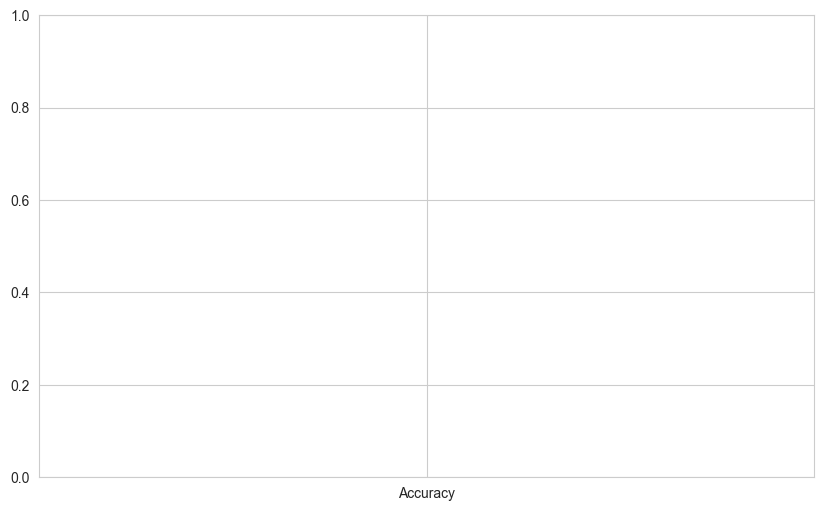

In [14]:
if __name__ == "__main__":
    train_and_evaluate()

In [ ]:
# 3/2 - Added KL annealing and weight decay to stabilize training and improve P-Disp.

if __name__ == "__main__":
    train_and_evaluate()

Environment setup complete. Seed=42.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2013.27it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gradient check passed.

--- Starting Training ---
Epoch 1/5 | Loss: 0.4014 | Val Acc: 0.8655 | Time: 1904.3s
Epoch 2/5 | Loss: 0.3170 | Val Acc: 0.8770 | Time: 2024.5s
Epoch 3/5 | Loss: 0.3170 | Val Acc: 0.8805 | Time: 2064.9s
Epoch 4/5 | Loss: 0.3248 | Val Acc: 0.8822 | Time: 3980.3s
Epoch 5/5 | Loss: 0.3336 | Val Acc: 0.8837 | Time: 1668.6s

--- Running Full Metric Suite ---
Clean Accuracy:  0.8859
Brier Score:     0.2716
ECE:             0.2524
ERU:             0.1500
P-Disc (AUROC):  0.8920
P-Disp (d):      0.0000

✅ All plots saved to reports/phase1/


/var/folders/m9/rkt0rxxd0tq9v1mxxz197j3w0000gn/T/ipykernel_48894/3326086397.py:196: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"{save_dir}/kl_discrepancy.png", dpi=200, bbox_inches='tight')
